✅ All libraries imported successfully!

✅ Dataset loaded successfully!
Shape of dataset: (20640, 9)

STEP 3: DATASET EXPLORATION

----- First 5 Rows -----
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

----- Dataset Info -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0

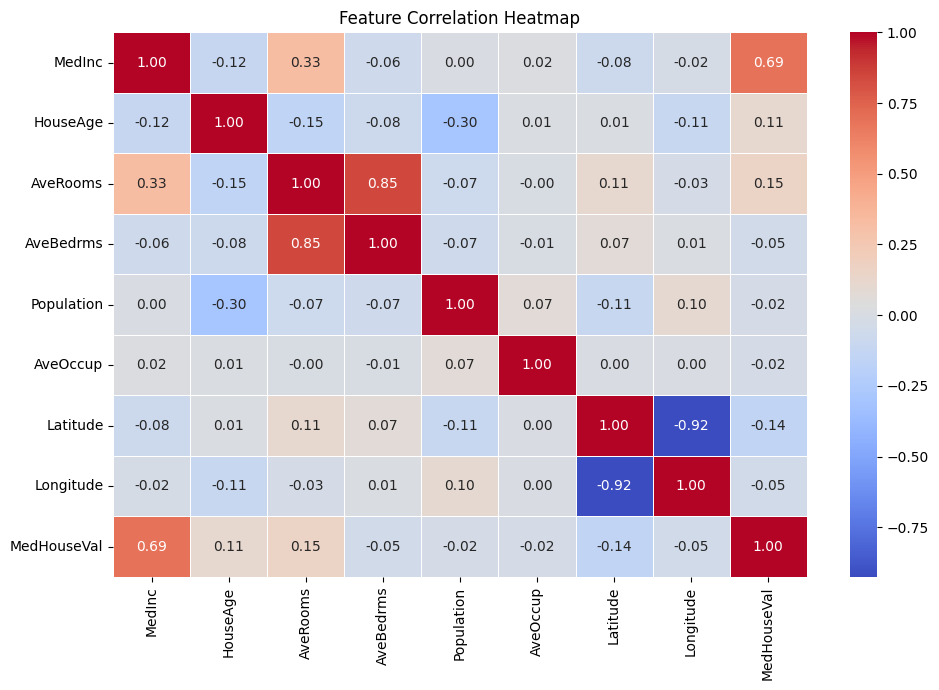

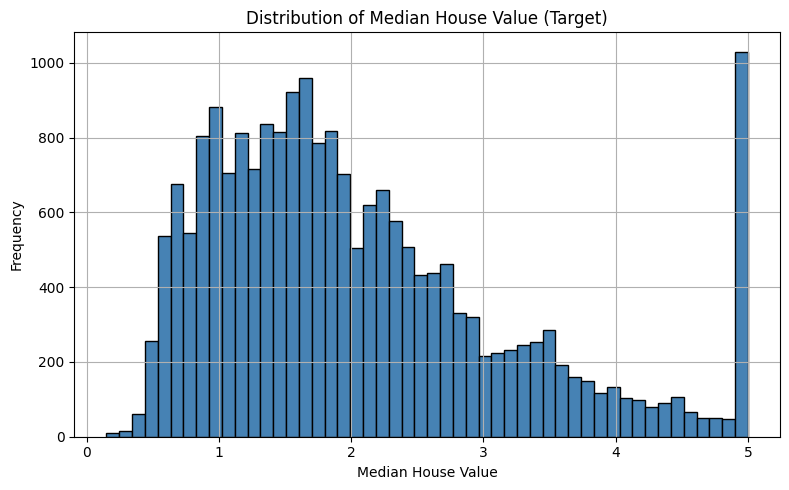


✅ Cell 1 Completed!
Run Cell 2 for Preprocessing and Linear Regression.


In [1]:
# ============================================================
# Machine Learning Lab Session 7
# Cell 1: Import Libraries, Load and Explore Dataset
# ============================================================

# ------------------------------------------------------------
# Step 1: Import Libraries
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

print("✅ All libraries imported successfully!")

# ------------------------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------------------------
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("\n✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

# ------------------------------------------------------------
# Step 3: Explore Dataset
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: DATASET EXPLORATION")
print("=" * 60)

# First 5 rows
print("\n----- First 5 Rows -----")
print(df.head())

# Dataset info
print("\n----- Dataset Info -----")
df.info()

# Statistical summary
print("\n----- Statistical Summary -----")
print(df.describe())

# Check missing values
print("\n----- Missing Values -----")
print(df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True,
            fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Distribution of Target Variable
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50,
         color='steelblue', edgecolor='black')
plt.title("Distribution of Median House Value (Target)")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Cell 1 Completed!")
print("Run Cell 2 for Preprocessing and Linear Regression.")

In [3]:
# ============================================================
# Machine Learning Lab Session 7
# Cell 2: Preprocessing and Linear Regression
# ============================================================

# ------------------------------------------------------------
# Step 4: Split Features and Target
# ------------------------------------------------------------
print("=" * 60)
print("STEP 4: SPLIT FEATURES AND TARGET")
print("=" * 60)

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features (X) shape :", X.shape)
print("Target (y) shape   :", y.shape)
print("Feature names      :", X.columns.tolist())
print("Target variable    : MedHouseVal (Median House Value)")

# ------------------------------------------------------------
# Step 5: Train-Test Split (80/20)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 5: TRAIN-TEST SPLIT (80/20)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size :", X_train.shape)
print("Testing set size  :", X_test.shape)

# ------------------------------------------------------------
# Step 6: Standardize Features
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 6: FEATURE SCALING (StandardScaler)")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ StandardScaler applied successfully.")
print("Mean of scaled training data (should be ~0):",
      X_train_scaled.mean().round(4))
print("Std of scaled training data (should be ~1) :",
      X_train_scaled.std().round(4))

# ------------------------------------------------------------
# Step 7: Train Linear Regression Model
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 7: TRAIN LINEAR REGRESSION MODEL")
print("=" * 60)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
linear_pred = model.predict(X_test_scaled)

print("✅ Linear Regression model trained successfully.")

# Model Coefficients
print("\nModel Coefficients:")
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")

# ------------------------------------------------------------
# Step 8: Evaluate Linear Regression
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 8: EVALUATE LINEAR REGRESSION")
print("=" * 60)

mae  = mean_absolute_error(y_test, linear_pred)
mse  = mean_squared_error(y_test, linear_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, linear_pred)

print(f"MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"MSE  (Mean Squared Error)  : {mse:.4f}")
print(f"RMSE (Root Mean Sq Error)  : {rmse:.4f}")
print(f"R²   (R-Squared Score)     : {r2:.4f}")

print("""
Interpretation:
- MAE  : Average absolute difference between
         actual and predicted values.
- MSE  : Penalizes larger errors more than MAE.
- RMSE : Same unit as target, easier to interpret.
- R²   : Closer to 1.0 means better model fit.
""")

print("\n✅ Cell 2 Completed!")
print("Run Cell 3 for Actual vs Predicted and Residual Plots.")

STEP 4: SPLIT FEATURES AND TARGET
Features (X) shape : (20640, 8)
Target (y) shape   : (20640,)
Feature names      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable    : MedHouseVal (Median House Value)

STEP 5: TRAIN-TEST SPLIT (80/20)
Training set size : (16512, 8)
Testing set size  : (4128, 8)

STEP 6: FEATURE SCALING (StandardScaler)
✅ StandardScaler applied successfully.
Mean of scaled training data (should be ~0): 0.0
Std of scaled training data (should be ~1) : 1.0

STEP 7: TRAIN LINEAR REGRESSION MODEL
✅ Linear Regression model trained successfully.

Model Coefficients:
   Feature  Coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929

Intercept: 2.0719

STEP 8: EVALUATE LINEAR REGRESSION
MAE  (Mean Absolute Error) : 0.5332
MSE  (Mean Squared Error)  : 0.5559
RMSE 

STEP 11: ACTUAL vs PREDICTED PLOT


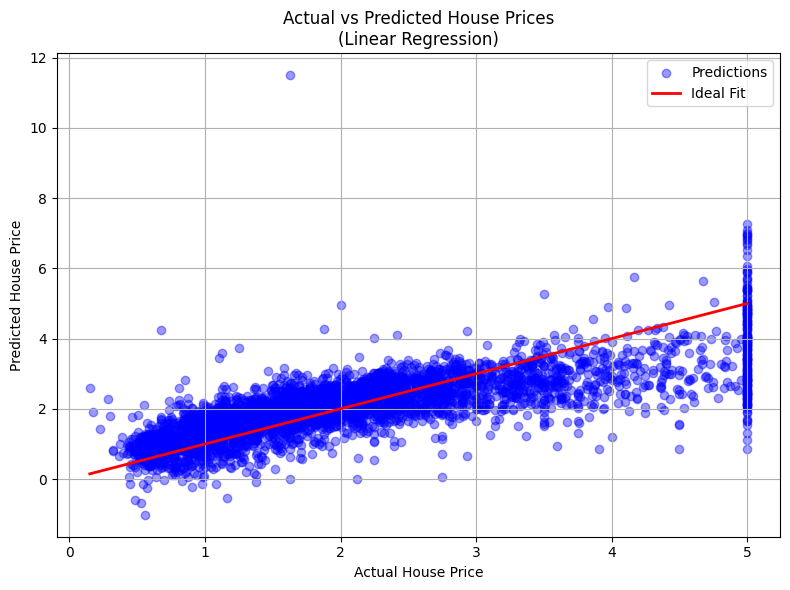


Plot Interpretation:
- Blue dots close to the red line = good predictions
- Blue dots far from the red line = poor predictions
- Perfect model = all dots on the red line


STEP 12: RESIDUAL PLOT


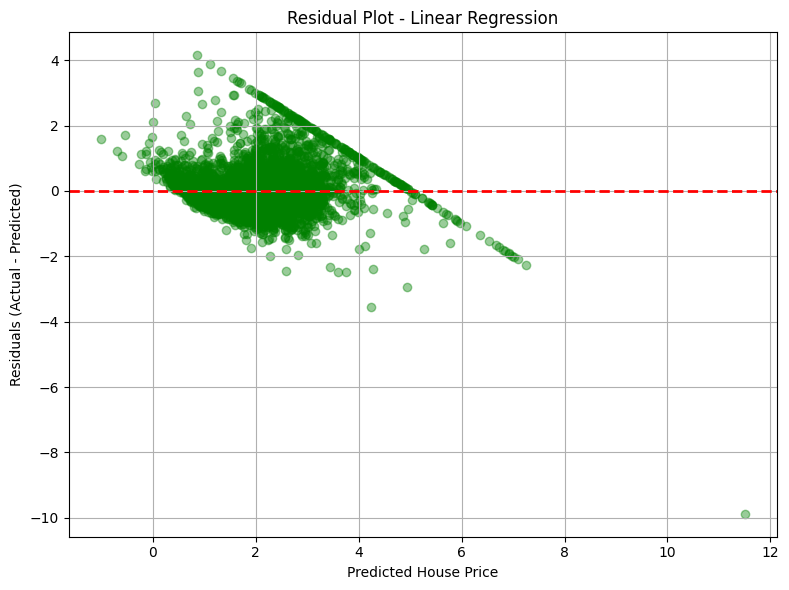

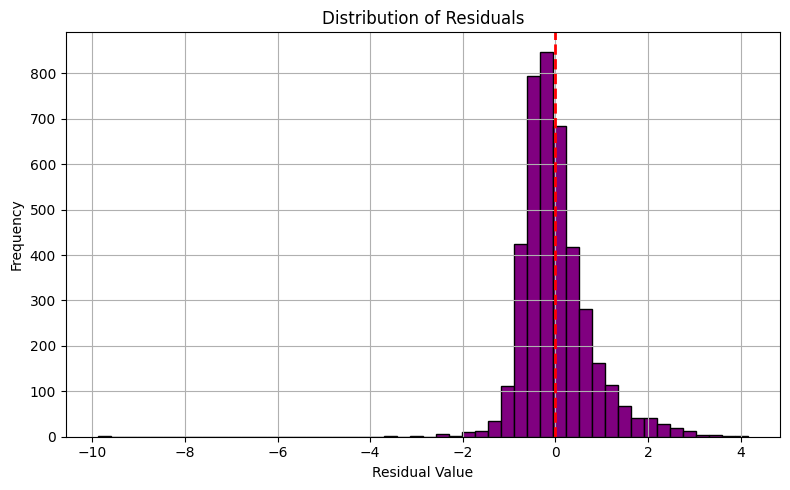


Residual Plot Interpretation:
- Points randomly scattered around 0 → Good model
- Patterns in residuals → Model is missing something
- Large residuals → Outliers or poor predictions
- Residuals centered at 0 → No bias in predictions


✅ Cell 3 Completed!
Run Cell 4 for Ridge, Lasso and Final Comparison.


In [4]:
# ============================================================
# Machine Learning Lab Session 7
# Cell 3: Actual vs Predicted Plot and Residual Plot
# ============================================================

# ------------------------------------------------------------
# Step 11: Actual vs Predicted Plot
# ------------------------------------------------------------
print("=" * 60)
print("STEP 11: ACTUAL vs PREDICTED PLOT")
print("=" * 60)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred,
            color='blue', alpha=0.4,
            label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2,
         label='Ideal Fit')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices\n(Linear Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("""
Plot Interpretation:
- Blue dots close to the red line = good predictions
- Blue dots far from the red line = poor predictions
- Perfect model = all dots on the red line
""")

# ------------------------------------------------------------
# Step 12: Residual Plot
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 12: RESIDUAL PLOT")
print("=" * 60)

residuals = y_test - linear_pred

# Residual Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(linear_pred, residuals,
            color='green', alpha=0.4)
plt.axhline(y=0, color='red',
            linestyle='--', linewidth=2)
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Distribution Plot
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50,
         color='purple', edgecolor='black')
plt.axvline(x=0, color='red',
            linestyle='--', linewidth=2)
plt.title("Distribution of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

print("""
Residual Plot Interpretation:
- Points randomly scattered around 0 → Good model
- Patterns in residuals → Model is missing something
- Large residuals → Outliers or poor predictions
- Residuals centered at 0 → No bias in predictions
""")

print("\n✅ Cell 3 Completed!")
print("Run Cell 4 for Ridge, Lasso and Final Comparison.")

STEP 9: TRAIN RIDGE REGRESSION (alpha=1.0)
✅ Ridge Regression trained successfully.
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758

Ridge Regression:
- Uses L2 Regularization
- Shrinks coefficients toward zero
- But NEVER makes them exactly zero
- Good when all features are useful


STEP 10: TRAIN LASSO REGRESSION (alpha=0.1)
✅ Lasso Regression trained successfully.
MAE  : 0.6222
MSE  : 0.6796
RMSE : 0.8244
R²   : 0.4814

Lasso Coefficients (zeros = feature eliminated):
   Feature  Coefficient
    MedInc     0.710598
  HouseAge     0.106453
  AveRooms    -0.000000
 AveBedrms     0.000000
Population    -0.000000
  AveOccup    -0.000000
 Longitude    -0.000000
  Latitude    -0.011469

Lasso Regression:
- Uses L1 Regularization
- Can make some coefficients EXACTLY zero
- Acts as automatic feature selection
- Good when only some features are useful


GRAPHICAL COMPARISON OF ALL THREE MODELS


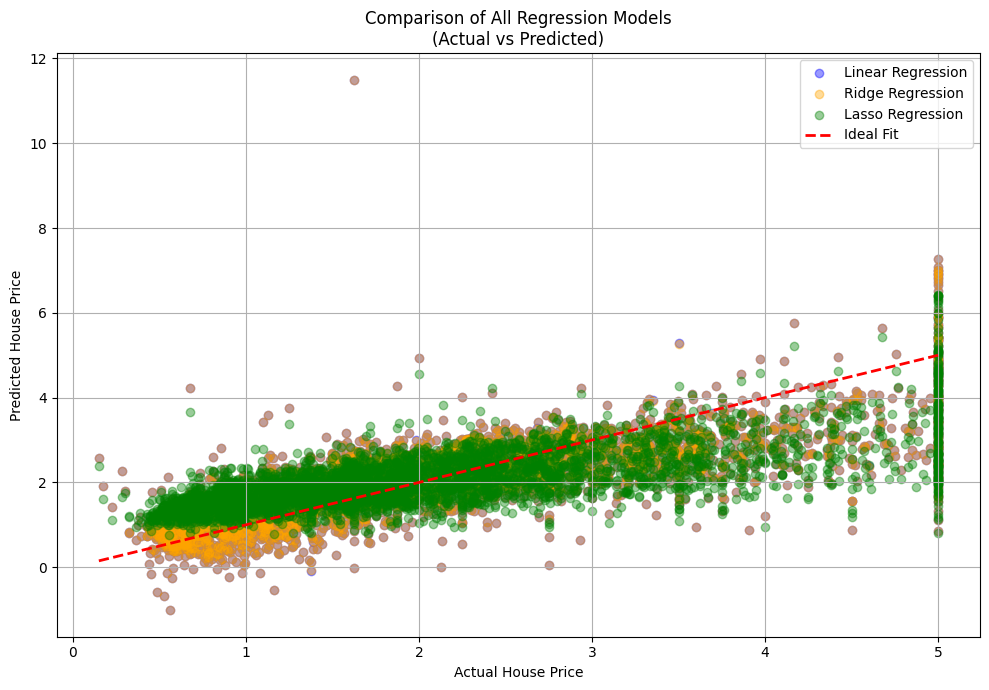

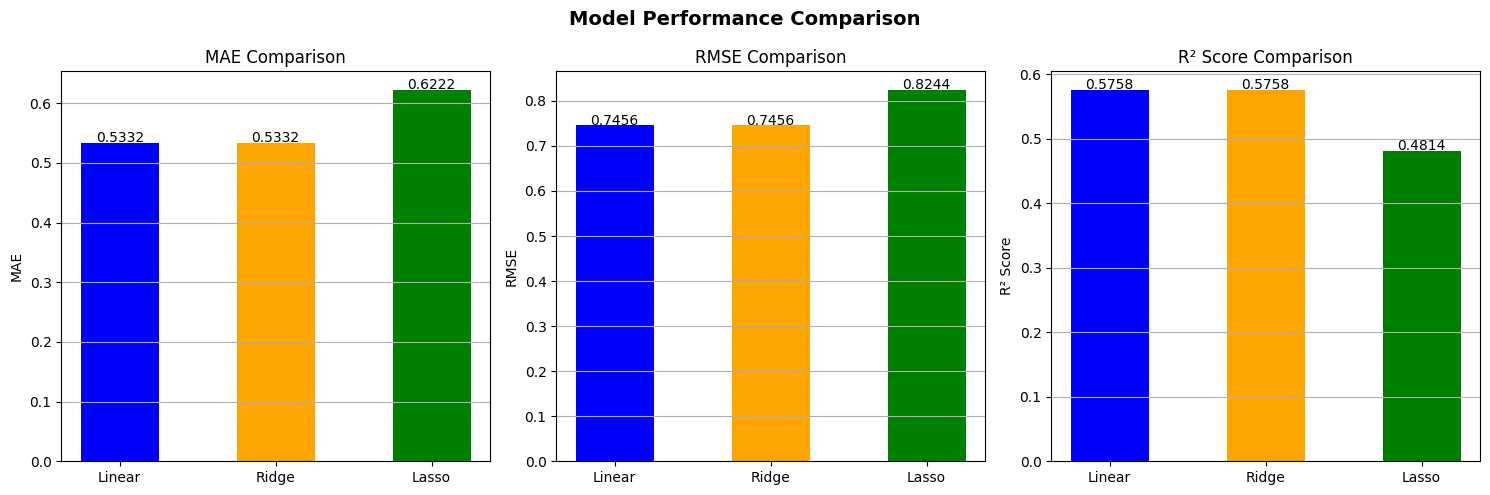

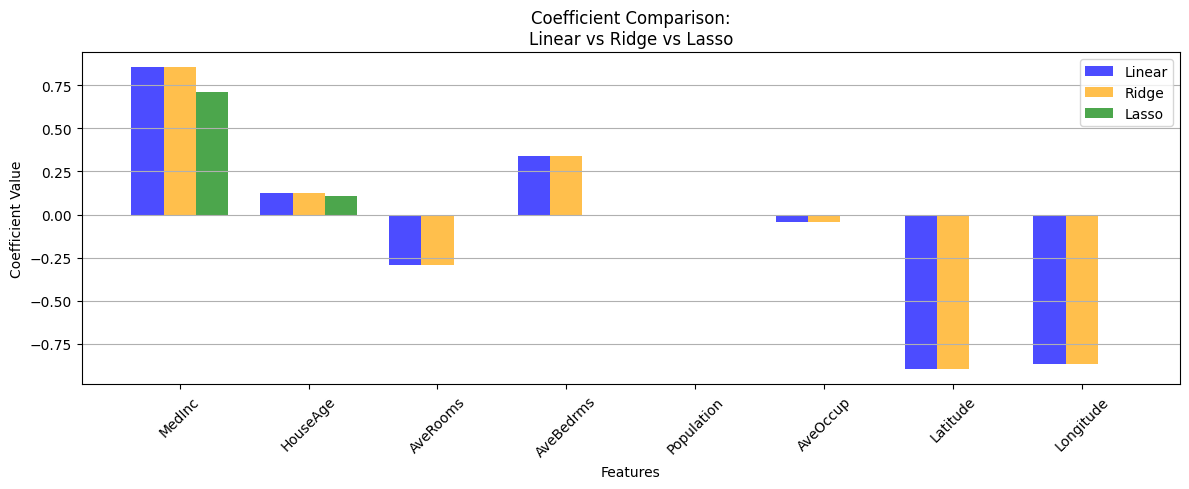


FINAL SUMMARY TABLE
            Model    MAE    MSE   RMSE     R²
Linear Regression 0.5332 0.5559 0.7456 0.5758
    Ridge (α=1.0) 0.5332 0.5559 0.7456 0.5758
    Lasso (α=0.1) 0.6222 0.6796 0.8244 0.4814

Key Observations:
- Linear Regression : No regularization.
                      Simple and interpretable.
                      Can overfit on noisy data.
- Ridge Regression  : L2 regularization.
                      Shrinks all coefficients.
                      Good when all features contribute.
- Lasso Regression  : L1 regularization.
                      Eliminates some features completely.
                      Good for feature selection.


✅ Cell 4 Completed!
🎉 Lab Session 7 Fully Completed!


In [5]:
# ============================================================
# Machine Learning Lab Session 7
# Cell 4: Ridge Regression, Lasso Regression
#          and Final Model Comparison
# ============================================================

# ------------------------------------------------------------
# Step 9: Train Ridge Regression (alpha=1.0)
# ------------------------------------------------------------
print("=" * 60)
print("STEP 9: TRAIN RIDGE REGRESSION (alpha=1.0)")
print("=" * 60)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

mae_ridge  = mean_absolute_error(y_test, ridge_pred)
mse_ridge  = mean_squared_error(y_test, ridge_pred)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge   = r2_score(y_test, ridge_pred)

print("✅ Ridge Regression trained successfully.")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

print("""
Ridge Regression:
- Uses L2 Regularization
- Shrinks coefficients toward zero
- But NEVER makes them exactly zero
- Good when all features are useful
""")

# ------------------------------------------------------------
# Step 10: Train Lasso Regression (alpha=0.1)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 10: TRAIN LASSO REGRESSION (alpha=0.1)")
print("=" * 60)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

mae_lasso  = mean_absolute_error(y_test, lasso_pred)
mse_lasso  = mean_squared_error(y_test, lasso_pred)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso   = r2_score(y_test, lasso_pred)

print("✅ Lasso Regression trained successfully.")
print(f"MAE  : {mae_lasso:.4f}")
print(f"MSE  : {mse_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.4f}")
print(f"R²   : {r2_lasso:.4f}")

# Lasso Coefficients
print("\nLasso Coefficients (zeros = feature eliminated):")
lasso_coef = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', ascending=False)
print(lasso_coef.to_string(index=False))

print("""
Lasso Regression:
- Uses L1 Regularization
- Can make some coefficients EXACTLY zero
- Acts as automatic feature selection
- Good when only some features are useful
""")

# ------------------------------------------------------------
# Graphical Comparison of all 3 Models
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("GRAPHICAL COMPARISON OF ALL THREE MODELS")
print("=" * 60)

# Plot 1: Actual vs Predicted for all 3 models
plt.figure(figsize=(10, 7))
plt.scatter(y_test, linear_pred,
            alpha=0.4, color='blue',
            label='Linear Regression')
plt.scatter(y_test, ridge_pred,
            alpha=0.4, color='orange',
            label='Ridge Regression')
plt.scatter(y_test, lasso_pred,
            alpha=0.4, color='green',
            label='Lasso Regression')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2,
         label='Ideal Fit')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Comparison of All Regression Models\n(Actual vs Predicted)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Bar Chart Metrics Comparison
models      = ['Linear', 'Ridge', 'Lasso']
mae_scores  = [mae,      mae_ridge,  mae_lasso]
rmse_scores = [rmse,     rmse_ridge, rmse_lasso]
r2_scores   = [r2,       r2_ridge,   r2_lasso]

x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE Comparison
axes[0].bar(x, mae_scores, width=0.5,
            color=['blue', 'orange', 'green'])
axes[0].set_title("MAE Comparison")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("MAE")
axes[0].grid(axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.002,
                 f"{v:.4f}",
                 ha='center', fontsize=10)

# RMSE Comparison
axes[1].bar(x, rmse_scores, width=0.5,
            color=['blue', 'orange', 'green'])
axes[1].set_title("RMSE Comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("RMSE")
axes[1].grid(axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.002,
                 f"{v:.4f}",
                 ha='center', fontsize=10)

# R² Comparison
axes[2].bar(x, r2_scores, width=0.5,
            color=['blue', 'orange', 'green'])
axes[2].set_title("R² Score Comparison")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylabel("R² Score")
axes[2].grid(axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.001,
                 f"{v:.4f}",
                 ha='center', fontsize=10)

plt.suptitle("Model Performance Comparison",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Coefficient Comparison
plt.figure(figsize=(12, 5))
x_features = np.arange(len(X.columns))
width = 0.25

plt.bar(x_features - width,
        model.coef_, width,
        label='Linear',
        color='blue', alpha=0.7)
plt.bar(x_features,
        ridge.coef_, width,
        label='Ridge',
        color='orange', alpha=0.7)
plt.bar(x_features + width,
        lasso.coef_, width,
        label='Lasso',
        color='green', alpha=0.7)

plt.xticks(x_features, X.columns, rotation=45)
plt.title("Coefficient Comparison:\nLinear vs Ridge vs Lasso")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final Summary Table
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)

summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Ridge (α=1.0)',
              'Lasso (α=0.1)'],
    'MAE' : [round(mae,       4),
             round(mae_ridge, 4),
             round(mae_lasso, 4)],
    'MSE' : [round(mse,       4),
             round(mse_ridge, 4),
             round(mse_lasso, 4)],
    'RMSE': [round(rmse,       4),
             round(rmse_ridge, 4),
             round(rmse_lasso, 4)],
    'R²'  : [round(r2,       4),
             round(r2_ridge, 4),
             round(r2_lasso, 4)]
})
print(summary.to_string(index=False))

print("""
Key Observations:
- Linear Regression : No regularization.
                      Simple and interpretable.
                      Can overfit on noisy data.
- Ridge Regression  : L2 regularization.
                      Shrinks all coefficients.
                      Good when all features contribute.
- Lasso Regression  : L1 regularization.
                      Eliminates some features completely.
                      Good for feature selection.
""")

print("\n✅ Cell 4 Completed!")
print("🎉 Lab Session 7 Fully Completed!")